# Energy Straggling Diagnostics

Visualise how energy straggling evolves as the beam traverses a multi-layer
target stack.  Three complementary views:

1. **Straggling vs depth** — $\sigma_E$ accumulation across layers
2. **Energy band** — mean energy $\pm 2\sigma$ shaded corridor
3. **Cross-section convolution** — point $\sigma(E)$ vs Gaussian-smeared $\langle\sigma\rangle(E)$

Uses the standard Mo-100 example with an initial beam energy spread.

## 1. Setup

In [1]:
%matplotlib inline

from hyrr import Beam, DataStore, Layer, TargetStack, compute_stack
from hyrr.materials import resolve_element
from hyrr.plotting import (
    plot_energy_band,
    plot_straggling_vs_depth,
    plot_xs_convolution,
)

db = DataStore("../nucl-parquet")

## 2. Define a multi-layer stack with beam energy spread

We use an enriched Mo-100 target behind a thin Cu degrader.
The beam has an initial energy spread of 0.3 MeV (typical cyclotron).

In [2]:
beam = Beam(
    projectile="p",
    energy_MeV=18.0,
    current_mA=0.15,
    energy_spread_MeV=0.3,
)

cu = resolve_element(db, "Cu")
mo100 = resolve_element(db, "Mo", enrichment={100: 1.0})

stack = TargetStack(
    beam=beam,
    layers=[
        Layer(
            density_g_cm3=8.96,
            elements=[(cu, 1.0)],
            thickness_cm=0.005,  # 50 um Cu degrader
        ),
        Layer(
            density_g_cm3=10.22,
            elements=[(mo100, 1.0)],
            energy_out_MeV=12.0,
        ),
    ],
    irradiation_time_s=86400.0,
    cooling_time_s=86400.0,
)

result = compute_stack(db, stack)
print(f"Layers: {len(result.layer_results)}")
for i, lr in enumerate(result.layer_results):
    print(f"  Layer {i}: E_in={lr.energy_in:.2f} -> E_out={lr.energy_out:.2f} MeV, "
          f"sigma_E: {lr.sigma_E_in_MeV:.4f} -> {lr.sigma_E_out_MeV:.4f} MeV")

Layers: 2
  Layer 0: E_in=18.00 -> E_out=17.20 MeV, sigma_E: 0.3000 -> 0.3053 MeV
  Layer 1: E_in=17.20 -> E_out=12.00 MeV, sigma_E: 0.3053 -> 0.3346 MeV


## 3. Straggling vs Depth

Shows $\sigma_E$ growing as the beam loses energy. The initial 0.3 MeV
spread from the cyclotron increases through Bohr straggling.

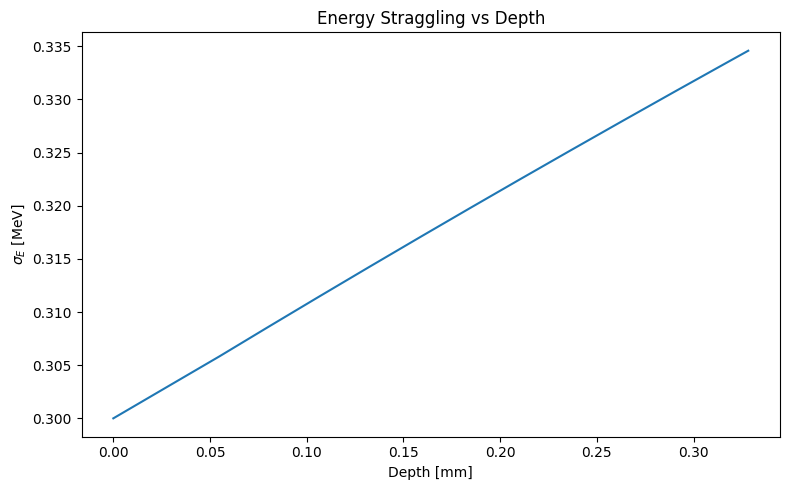

In [3]:
plot_straggling_vs_depth(result.layer_results)

## 4. Energy Band

Mean beam energy $E(z)$ with a shaded $\pm 2\sigma$ band.
Layer boundaries are marked with dashed vertical lines.

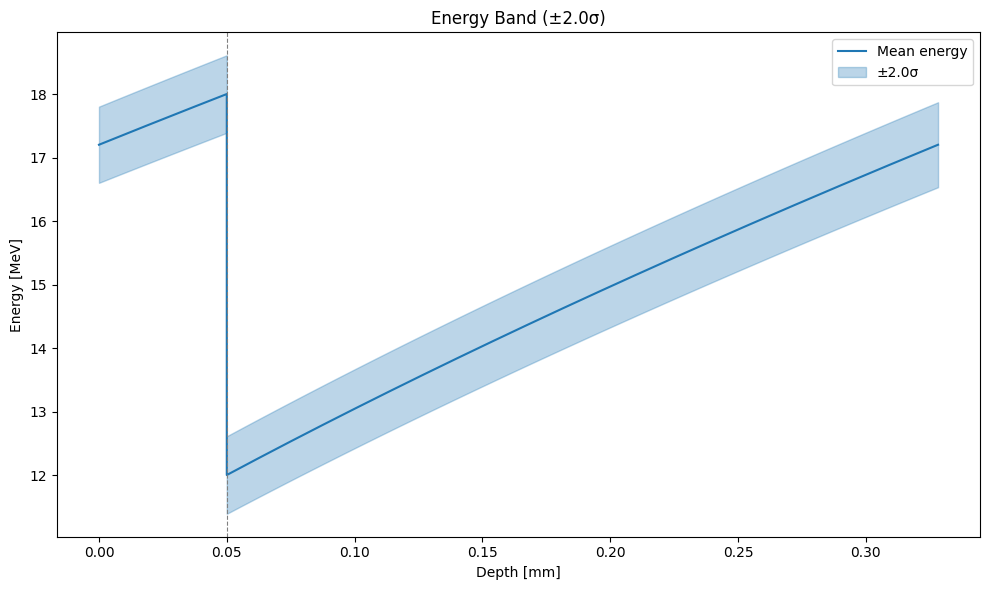

In [4]:
plot_energy_band(result.layer_results, n_sigma=2.0)

## 5. Cross-Section Convolution

Compare the point cross-section $\sigma(E)$ with the Gaussian-smeared
$\langle\sigma\rangle(E)$ for a representative reaction.
The convolution broadens and shifts thresholds, increasing yield
for reactions with thresholds near the beam energy.

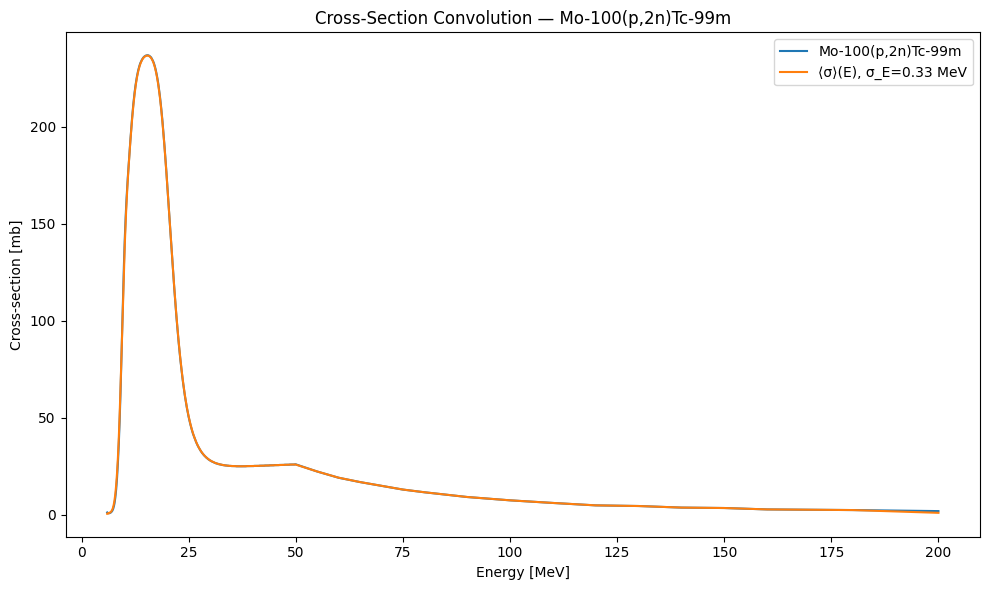

In [5]:
import numpy as np

# Get cross-section data for Mo-100(p,2n)Tc-99m
xs_data = db.get_cross_sections("p", 42, 100)
for xs in xs_data:
    if xs.residual_Z == 43 and xs.residual_A == 99 and xs.state == "m":
        energies = np.array(xs.energies_MeV)
        sigmas = np.array(xs.xs_mb)
        break

plot_xs_convolution(
    energies,
    sigmas,
    sigma_E_MeV=result.layer_results[-1].sigma_E_out_MeV,
    reaction_label="Mo-100(p,2n)Tc-99m",
)